In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
try:
    # Load data fitur (X) dari BoW yang sudah bersih
    X = pd.read_csv('../Week3/bow_features_cleaned.csv')
    
    # Muat data asli untuk mendapatkan label sentimen (y)
    df_labels = pd.read_csv('../Week2/df_tj_sentiment_analysis.csv')
    y = df_labels['sentiment_rating']
    
    # Menghapus baris di mana sentimen adalah NaN (jika ada)
    # dan menyelaraskan X dan y
    valid_indices = y.notna()
    y = y[valid_indices]
    X = X[valid_indices]

    print("Data fitur (X) dan target (y) berhasil dimuat dan diselaraskan.")
    print(f"Jumlah data yang akan digunakan: {len(y)} ulasan.")

except FileNotFoundError as e:
    print(f"Error: File tidak ditemukan. {e}")
    # Hentikan eksekusi jika file tidak ada
    exit()

Data fitur (X) dan target (y) berhasil dimuat dan diselaraskan.
Jumlah data yang akan digunakan: 3016 ulasan.


In [3]:
# Membagi Data
# Kita bagi data menjadi 80% untuk melatih model dan 20% untuk menguji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, # random_state agar hasil pembagian data selalu sama
    stratify=y # stratify untuk memastikan proporsi sentimen sama di data train & test
)

print(f"\nData dibagi menjadi {len(X_train)} data latih dan {len(X_test)} data uji.")


Data dibagi menjadi 2412 data latih dan 604 data uji.


In [4]:
# Melatih Model Naive Bayes
# Kita menggunakan MultinomialNB yang cocok
model = MultinomialNB()
model.fit(X_train, y_train)

print("\nModel Naive Bayes berhasil dilatih.")


Model Naive Bayes berhasil dilatih.



--- Hasil Evaluasi Model ---
Akurasi Model: 89.90%

Laporan Klasifikasi:
              precision    recall  f1-score   support

    Negative       0.71      0.79      0.75       107
     Neutral       0.00      0.00      0.00        20
    Positive       0.95      0.96      0.96       477

    accuracy                           0.90       604
   macro avg       0.55      0.58      0.57       604
weighted avg       0.88      0.90      0.89       604


Confusion Matrix:


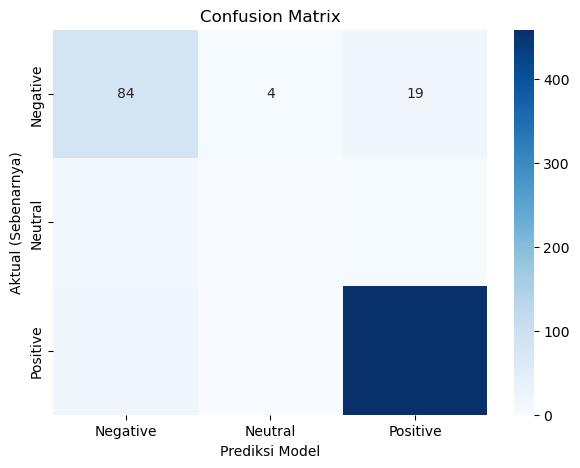

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Lakukan prediksi pada data uji
y_pred = model.predict(X_test) 

# 1. Tentukan label unik yang benar-benar ada di data uji
# Ini adalah perbaikan utamanya!
try:
    # Coba ambil label unik dari y_test (mengubah ke list jika berupa Series/array)
    actual_labels = sorted(np.unique(y_test).tolist())
except Exception:
    # Sebagai fallback, jika y_test kosong atau bermasalah, gunakan label hardcode
    actual_labels = ['Positive', 'Neutral', 'Negative']
    print("Peringatan: Gagal mendapatkan label unik dari y_test. Menggunakan label default.")


# 2. Hitung Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Hasil Evaluasi Model ---")
print(f"Akurasi Model: {accuracy:.2%}")

# 3. Tampilkan Laporan Klasifikasi
print("\nLaporan Klasifikasi:")
# classification_report secara otomatis menyesuaikan label
print(classification_report(y_test, y_pred))

# 4. Tampilkan Confusion Matrix
print("\nConfusion Matrix:")

# Hitung Confusion Matrix menggunakan label yang teridentifikasi secara otomatis
cm = confusion_matrix(y_test, y_pred, labels=actual_labels)

# Visualisasi Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=actual_labels, # Menggunakan label aktual
            yticklabels=actual_labels)  # Menggunakan label aktual

plt.xlabel('Prediksi Model')
plt.ylabel('Aktual (Sebenarnya)')
plt.title('Confusion Matrix')
plt.show()

Kosakata final yang akan digunakan untuk kedua model: 1318 kata.
Matriks TF-IDF berhasil dibuat dengan ukuran yang konsisten: (3016, 1318)

--- Tampilan Matriks TF-IDF (10 Ulasan Pertama dengan 15 kolom) ---


,00,06,07,09,10,11w,12,120,12b,13,14,15,1f,1jam,20
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Data dibagi menjadi 2412 data latih dan 604 data uji.

Model Naive Bayes (TF-IDF) berhasil dilatih.

--- Hasil Evaluasi Model (TF-IDF) ---
Akurasi Model: 89.07%

Laporan Klasifikasi:
              precision    recall  f1-score   support

    Negative       0.81      0.62      0.70       107
     Neutral       0.00      0.00      0.00        20
    Positive       0.90      0.99      0.94       477

    accuracy                           0.89       604
   macro avg       0.57      0.54      0.55       604
weighted avg       0.86      0.89      0.87       604


Confusion Matrix:


c:\Users\Anas G\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Anas G\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Anas G\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


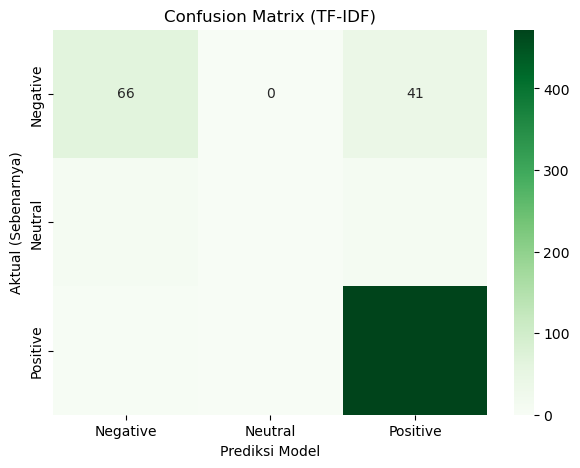

In [19]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

try:
    # 1. Muat BoW yang sudah bersih HANYA untuk mengambil daftar katanya (kosakata)
    bow_cleaned_df = pd.read_csv('../Week3/bow_features_cleaned.csv')
    final_vocabulary = bow_cleaned_df.columns.tolist()
    print(f"Kosakata final yang akan digunakan untuk kedua model: {len(final_vocabulary)} kata.")

    # 2. Muat data yang berisi TEKS BERSIH dan TARGET LABEL
    df_cleaned = pd.read_csv('../Week2/df_tj_sentiment_analysis.csv')
    
    df_cleaned['cleaned_content_no_common'] = df_cleaned['cleaned_content_no_common'].fillna('')
    df_cleaned.dropna(subset=['sentiment_rating'], inplace=True)

    # 3. Persiapkan Input Teks dan Target Label
    X_text = df_cleaned['cleaned_content_no_common']
    y = df_cleaned['sentiment_rating']

    # 4. Buat Matriks TF-IDF dengan Kosakata yang Telah Ditentukan
    tfidf_vectorizer = TfidfVectorizer(vocabulary=final_vocabulary)
    X_tfidf = tfidf_vectorizer.fit_transform(X_text)
    
    print(f"Matriks TF-IDF berhasil dibuat dengan ukuran yang konsisten: {X_tfidf.shape}")

    # Buat DataFrame dari matriks TF-IDF untuk ditampilkan
    tfidf_df_display = pd.DataFrame(X_tfidf.toarray(), columns=final_vocabulary)
    
    print("\n--- Tampilan Matriks TF-IDF (10 Ulasan Pertama dengan 15 kolom) ---")
    display(tfidf_df_display.iloc[:10, :15])

    # 5. Membagi Data
    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y
    )
    print(f"Data dibagi menjadi {len(y_train)} data latih dan {len(y_test)} data uji.")

    # 6. Latih dan Evaluasi Model
    model_tfidf = MultinomialNB()
    model_tfidf.fit(X_train, y_train)
    print("\nModel Naive Bayes (TF-IDF) berhasil dilatih.")

    y_pred = model_tfidf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n--- Hasil Evaluasi Model (TF-IDF) ---")
    print(f"Akurasi Model: {accuracy:.2%}")

    print("\nLaporan Klasifikasi:")
    print(classification_report(y_test, y_pred))
    
    # 7. PERBAIKAN CONFUSION MATRIX 👇

    print("\nConfusion Matrix:")
    
    # Ambil label unik yang benar-benar ada di data uji, lalu urutkan
    # Urutan label ini akan menjadi baris/kolom di matriks
    actual_labels = sorted(np.unique(y_test).tolist())

    # Hitung Confusion Matrix hanya untuk label yang ada
    cm = confusion_matrix(y_test, y_pred, labels=actual_labels)

    # Visualisasi Heatmap menggunakan label yang teridentifikasi secara otomatis
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=actual_labels, 
                yticklabels=actual_labels) 
                
    plt.xlabel('Prediksi Model')
    plt.ylabel('Aktual (Sebenarnya)')
    plt.title('Confusion Matrix (TF-IDF)')
    plt.show()

except FileNotFoundError as e:
    print(f"\nERROR: Salah satu file input tidak ditemukan: {e}")
    print("Pastikan Anda memiliki 'bow_features_cleaned.csv' dan 'df_tj_sentiment_analysis.csv' di lokasi yang benar.")

except Exception as e:
    print(f"\nTerjadi kesalahan tak terduga: {e}")

Matriks TF-IDF berhasil dibuat dengan ukuran: (3016, 1318)
Data dibagi menjadi 2412 data latih dan 604 data uji.

Model Logistic Regression berhasil dilatih.

--- Hasil Evaluasi Model (Logistic Regression) ---
Akurasi Model: 83.61%

Laporan Klasifikasi:
              precision    recall  f1-score   support

    Positive       0.98      0.87      0.92       477
     Neutral       0.21      0.30      0.25        20
    Negative       0.56      0.80      0.66       107

    accuracy                           0.84       604
   macro avg       0.58      0.66      0.61       604
weighted avg       0.88      0.84      0.85       604


Confusion Matrix:


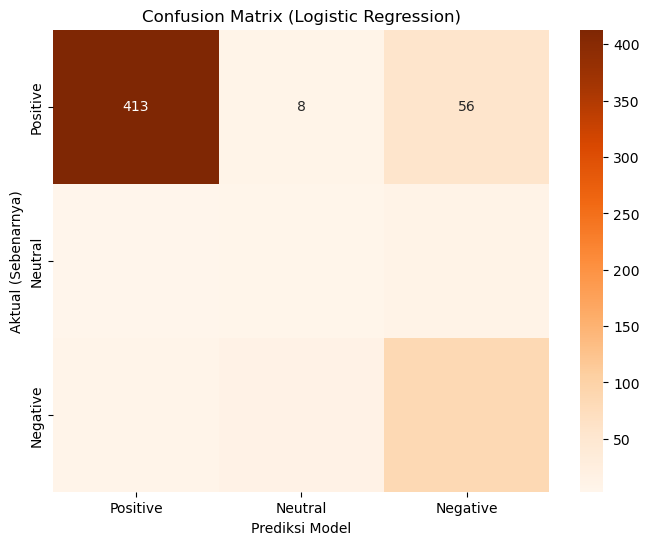

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

try:
    # 1. Muat BoW yang sudah bersih HANYA untuk mengambil daftar katanya (kosakata)
    bow_cleaned_df = pd.read_csv('../Week3/bow_features_cleaned.csv')
    final_vocabulary = bow_cleaned_df.columns.tolist()

    # 2. Muat data yang berisi TEKS BERSIH dan LABEL SENTIMEN
    df_cleaned = pd.read_csv('../Week2/df_tj_sentiment_analysis.csv')
    df_cleaned['cleaned_content_no_common'] = df_cleaned['cleaned_content_no_common'].fillna('')
    df_cleaned.dropna(subset=['sentiment_rating'], inplace=True)

    # 3. Persiapkan Input Teks dan Target Label
    X_text = df_cleaned['cleaned_content_no_common']
    y = df_cleaned['sentiment_rating']

    # 4. Buat Matriks TF-IDF dengan Kosakata yang Telah Ditentukan
    tfidf_vectorizer = TfidfVectorizer(vocabulary=final_vocabulary)
    X_tfidf = tfidf_vectorizer.fit_transform(X_text)
    
    print(f"Matriks TF-IDF berhasil dibuat dengan ukuran: {X_tfidf.shape}")

    # 5. Membagi Data (BAGIAN PERBAIKAN)
    # Anda sudah menggunakan stratify=y, ini adalah langkah yang benar
    # untuk memastikan data uji memiliki perwakilan dari setiap kelas.
    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y  # <-- Ini adalah perbaikan kuncinya!
    )
    print(f"Data dibagi menjadi {len(y_train)} data latih dan {len(y_test)} data uji.")

    # 6. Latih Model Logistic Regression
    # Parameter class_weight='balanced' juga bagus untuk menangani data tidak seimbang
    logreg_model = LogisticRegression(
        class_weight='balanced', 
        random_state=42,
        max_iter=1000 # Menambah iterasi agar model konvergen
    )
    logreg_model.fit(X_train, y_train)
    print("\nModel Logistic Regression berhasil dilatih.")

    # 7. Evaluasi Model
    y_pred = logreg_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n--- Hasil Evaluasi Model (Logistic Regression) ---")
    print(f"Akurasi Model: {accuracy:.2%}")

    print("\nLaporan Klasifikasi:")
    # Mendefinisikan urutan label agar laporan dan plot konsisten
    labels_order = ['Positive', 'Neutral', 'Negative']
    print(classification_report(y_test, y_pred, labels=labels_order))
    
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred, labels=labels_order)
    
    plt.figure(figsize=(8, 6)) # Menambahkan plt.figure agar ukuran plot teraplikasi
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
                xticklabels=labels_order, 
                yticklabels=labels_order)
    plt.xlabel('Prediksi Model')
    plt.ylabel('Aktual (Sebenarnya)')
    plt.title('Confusion Matrix (Logistic Regression)')
    plt.show()

except FileNotFoundError as e:
    print(f"Error: Pastikan file 'bow_features_cleaned.csv' dan 'df_tj_clean.csv' ada di folder yang sama. {e}")
except Exception as e:
    print(f"Terjadi error lain: {e}")